In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import pingouin as pg
from pathlib import Path
from glob import glob
from scipy import stats
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns
import os.path as op
import re

In [2]:
# Setup directories and plotting theme
data_dir = "dset"
#raw_annot_dir = op.join(data_dir, "annotations")
deriv_dir = op.join(data_dir, "derivatives")
raw_annot_dir = op.join(data_dir, "annotations")

# # Create directories
# OUT_DIR.mkdir(parents=True, exist_ok=True)
# FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Configure plotting theme
sns.set_theme(style="darkgrid")

# Define colors for consistent plotting
colors = ["#11FF00", "#FF0800", "#F6FF00", "#FF00CC", "#0400FF", "#00eeff", '#e377c2', '#BCB5BB']

In [3]:
episode_numbers = [1, 2, 3, 4]
run_numbers = range(0, 8)

episode_csvs = {}

for ep_num in episode_numbers:
    episode_key = f"S01E{ep_num:02d}"
    episode_dir = op.join(raw_annot_dir, episode_key)

    run_csvs = {}
    for i in run_numbers:
        run_key = f"R0{i}"
        csv_pattern = op.join(episode_dir, f"{episode_key}{run_key}*.csv")
        csv_files = sorted(glob(csv_pattern))
        if csv_files:
            run_csvs[run_key] = csv_files

    episode_csvs[episode_key] = run_csvs

    print(f"{episode_key}: {len(run_csvs)} runs with CSVs")
    for run_key, files in run_csvs.items():
        print(f"  {run_key}: {len(files)} CSV files")
        for file_path in files:
            rater_df = pd.read_csv(file_path)
            print(f"    {op.basename(file_path)} -> {rater_df.shape}")
            
    print()

S01E01: 6 runs with CSVs
  R01: 4 CSV files
    S01E01R01_002.csv -> (334, 3)
    S01E01R01_003.csv -> (334, 3)
    S01E01R01_005.csv -> (334, 3)
    S01E01R01_008.csv -> (334, 3)
  R02: 5 CSV files
    S01E01R02_001.csv -> (276, 3)
    S01E01R02_002.csv -> (276, 3)
    S01E01R02_003.csv -> (276, 3)
    S01E01R02_004.csv -> (276, 3)
    S01E01R02_008.csv -> (276, 3)
  R03: 3 CSV files
    S01E01R03_004.csv -> (275, 3)
    S01E01R03_005.csv -> (275, 3)
    S01E01R03_006.csv -> (275, 3)
  R04: 3 CSV files
    S01E01R04_001.csv -> (286, 3)
    S01E01R04_005.csv -> (286, 3)
    S01E01R04_008.csv -> (286, 3)
  R05: 4 CSV files
    S01E01R05_003.csv -> (312, 3)
    S01E01R05_005.csv -> (312, 3)
    S01E01R05_006.csv -> (312, 3)
    S01E01R05_008.csv -> (312, 3)
  R06: 4 CSV files
    S01E01R06_003.csv -> (333, 3)
    S01E01R06_005.csv -> (333, 3)
    S01E01R06_006.csv -> (333, 3)
    S01E01R06_008.csv -> (333, 3)

S01E02: 7 runs with CSVs
  R01: 3 CSV files
    S01E02R01_004.csv -> (313, 3)


    S01E02R07_007.csv -> (294, 3)
    S01E02R07_008.csv -> (294, 3)

S01E03: 0 runs with CSVs

S01E04: 6 runs with CSVs
  R01: 4 CSV files
    S01E04R01_003.csv -> (307, 3)
    S01E04R01_005.csv -> (307, 3)
    S01E04R01_007.csv -> (307, 3)
    S01E04R01_008.csv -> (307, 3)
  R02: 3 CSV files
    S01E04R02_006.csv -> (296, 3)
    S01E04R02_007.csv -> (296, 3)
    S01E04R02_008.csv -> (296, 3)
  R03: 3 CSV files
    S01E04R03_006.csv -> (293, 3)
    S01E04R03_007.csv -> (293, 3)
    S01E04R03_008.csv -> (293, 3)
  R04: 3 CSV files
    S01E04R04_004.csv -> (334, 3)
    S01E04R04_005.csv -> (334, 3)
    S01E04R04_008.csv -> (334, 3)
  R05: 3 CSV files
    S01E04R05_001.csv -> (230, 3)
    S01E04R05_002.csv -> (230, 3)
    S01E04R05_004.csv -> (230, 3)
  R06: 3 CSV files
    S01E04R06_001.csv -> (431, 3)
    S01E04R06_002.csv -> (431, 3)
    S01E04R06_004.csv -> (431, 3)



R01 Valence:
  Overall avg pairwise Spearman: 0.611
  Rater 002: corr with mean of others: 0.734, avg corr without: 0.621
  Rater 003: corr with mean of others: 0.692, avg corr without: 0.557
  Rater 005: corr with mean of others: 0.743, avg corr without: 0.659
  Rater 008: corr with mean of others: 0.716, avg corr without: 0.607
R01 Arousal:
  Overall avg pairwise Spearman: 0.521
  Rater 002: corr with mean of others: 0.487, avg corr without: 0.510
  Rater 003: corr with mean of others: 0.770, avg corr without: 0.591
  Rater 005: corr with mean of others: 0.505, avg corr without: 0.492
  Rater 008: corr with mean of others: 0.605, avg corr without: 0.490

R02 Valence:
  Overall avg pairwise Spearman: 0.683
  Rater 001: corr with mean of others: 0.717, avg corr without: 0.640
  Rater 002: corr with mean of others: 0.825, avg corr without: 0.706
  Rater 003: corr with mean of others: 0.835, avg corr without: 0.716
  Rater 004: corr with mean of others: 0.789, avg corr without: 0.686
  R

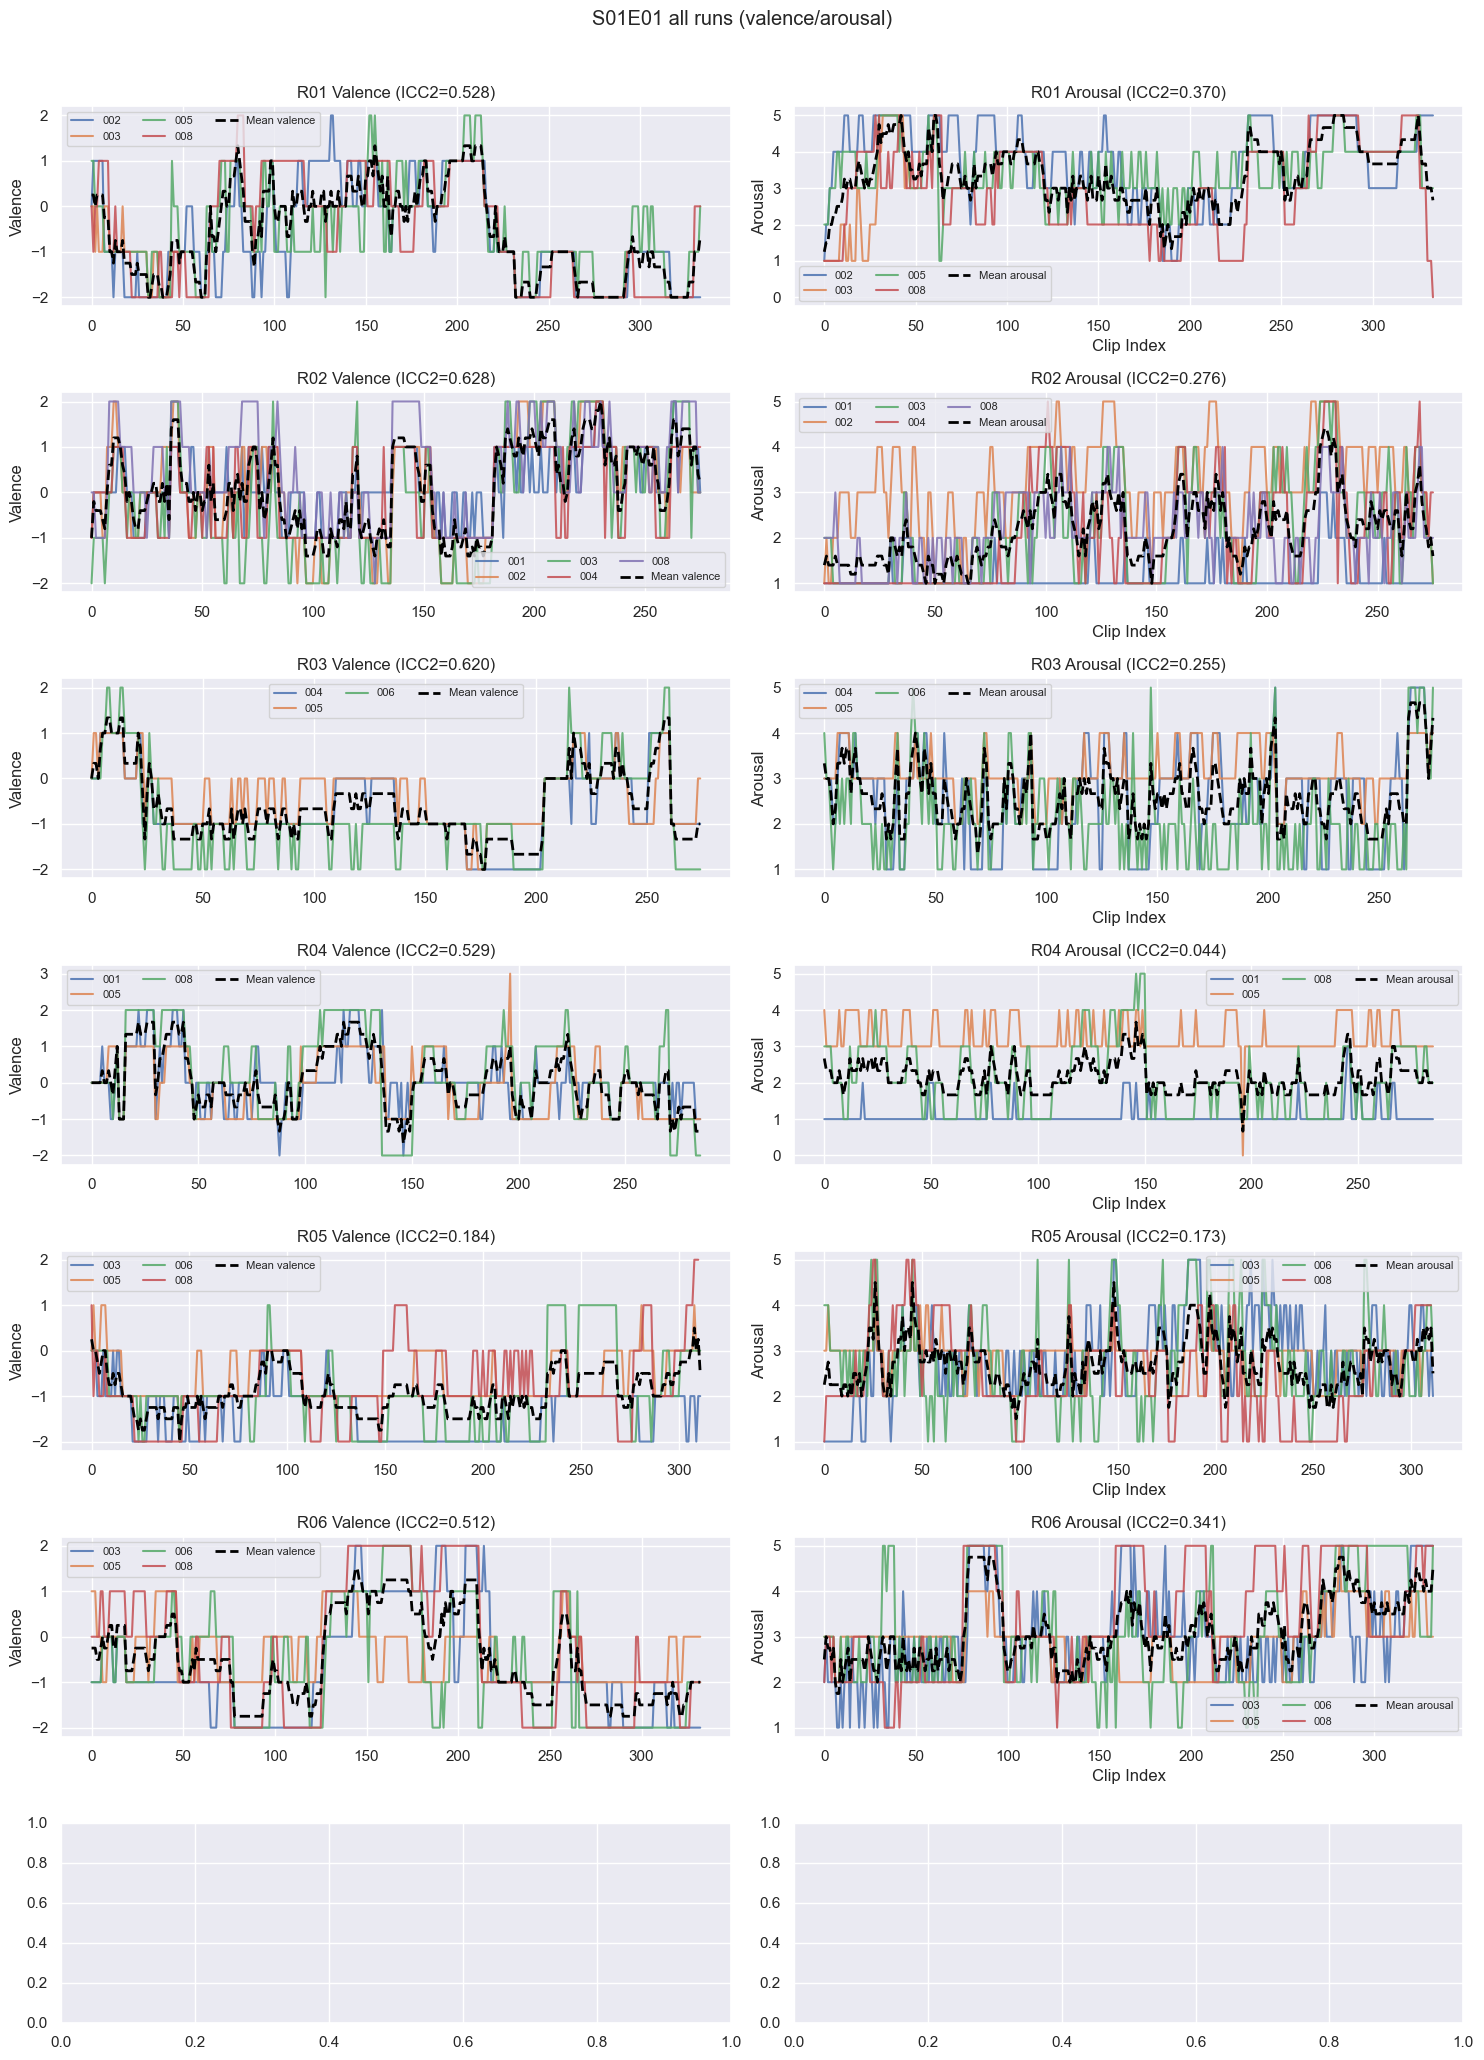

In [ ]:
def compute_correlations(dfs, rating_type):
    if not dfs:
        return None
    
    wide_df = pd.DataFrame()
    raters = []
    for df in dfs:
        rater = df['rater'].iloc[0] # get rater name from 
        raters.append(rater)
        wide_df[rater] = df.set_index('time')[rating_type] # make time the index and then make raters as columns 

    corr_matrix = wide_df.corr(method='spearman')
    # set spearman ranked test as the correlation for the data frame

    import numpy as np
    triu_indices = np.triu_indices_from(corr_matrix, k=1)
    overall_avg_corr = corr_matrix.values[triu_indices].mean()  
    # get overall spearman correlation per run 

    results = {}
    for rater in raters:
        others = [r for r in raters if r != rater]
        if not others:
            continue

        # run spearman with the mean of other raters
        mean_others = wide_df[others].mean(axis=1)
        corr_with_mean = wide_df[rater].corr(mean_others, method='spearman')    

        # run spearman with every rater
        if len(others) > 1:
            corr_without = wide_df[others].corrwith(wide_df[rater], method='spearman')
            avg_corr_without = corr_without.mean()
        else:
            avg_corr_without = corr_with_mean

        results[rater] = {
            'corr_with_mean': corr_with_mean,
            'avg_corr_without': avg_corr_without
        
        }
    return {
        'overall_avg_corr': overall_avg_corr,
        'per_rater': results
    }

episode_to_plot = "S01E01"
runs_to_plot = ["R01", "R02", "R03", "R04", "R05", "R06", "R07"]

# plotting valence and arousal for each run of the selected episode
n_runs = len(runs_to_plot)
fig, axs = plt.subplots(n_runs, 2, figsize=(15, 3 * n_runs), sharex=False)
fig.suptitle(f"{episode_to_plot} all runs (valence/arousal)")

for i, run_to_plot in enumerate(runs_to_plot):
    run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
    if not run_files:
        continue

    ax_val = axs[i, 0]
    ax_aro = axs[i, 1]
    dfs_val = []
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")
        if val_col is None or aro_col is None:
            continue

        rater_label = op.basename(file_path).split("_")[-1].replace(".csv", "")
        values = pd.to_numeric(df[val_col], errors="coerce")
        aros = pd.to_numeric(df[aro_col], errors="coerce")
        times = np.arange(len(df))

        dfs_val.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "valence": values
        }))
        dfs_aro.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "arousal": aros
        }))

        ax_val.plot(values.to_numpy(), label=rater_label, alpha=0.85)
        ax_aro.plot(aros.to_numpy(), label=rater_label, alpha=0.85)
    if dfs_val:
        wide_val = pd.DataFrame({
            df['rater'].iloc[0]: df.set_index('time')['valence']
            for df in dfs_val
    # plot average with graph
        })
        avg_val = wide_val.mean(axis=1)
        ax_val.plot(avg_val.index, avg_val.values,
                    color='black', linestyle='--', linewidth=2,
                    label='Mean valence')

    if dfs_aro:
        wide_aro = pd.DataFrame({
            df['rater'].iloc[0]: df.set_index('time')['arousal']
            for df in dfs_aro
     # plot average with graph

        })
        avg_aro = wide_aro.mean(axis=1)
        ax_aro.plot(avg_aro.index, avg_aro.values,
                    color='black', linestyle='--', linewidth=2,
                    label='Mean arousal')
# calculating ICC2 for valence and arousal

    icc_val = np.nan
    icc_aro = np.nan

    if dfs_val:
        long_df_val = pd.concat(dfs_val, ignore_index=True).dropna()
        if not long_df_val.empty:
            icc_result_val = pg.intraclass_corr(
                data=long_df_val,
                targets="time",
                raters="rater",
                ratings="valence",
                nan_policy="omit"
            )
            icc_val_series = icc_result_val.loc[icc_result_val["Type"] == "ICC2", "ICC"]
            if not icc_val_series.empty:
                icc_val = float(icc_val_series.values[0])

    if dfs_aro:
        long_df_aro = pd.concat(dfs_aro, ignore_index=True).dropna()
        if not long_df_aro.empty:
            icc_result_aro = pg.intraclass_corr(
                data=long_df_aro,
                targets="time",
                raters="rater",
                ratings="arousal",
                nan_policy="omit"
            )
            icc_aro_series = icc_result_aro.loc[icc_result_aro["Type"] == "ICC2", "ICC"]
            if not icc_aro_series.empty:
                icc_aro = float(icc_aro_series.values[0])

    ax_val.set_title(f"{run_to_plot} Valence (ICC2={icc_val:.3f})")
    ax_val.set_ylabel("Valence")
    ax_val.legend(fontsize=8, ncol=3)

    ax_aro.set_title(f"{run_to_plot} Arousal (ICC2={icc_aro:.3f})")
    ax_aro.set_ylabel("Arousal")
    ax_aro.set_xlabel("Clip Index")
    ax_aro.legend(fontsize=8, ncol=3)
# correlations with spearman with and without the specific raters per run
    corr_val = compute_correlations(dfs_val, 'valence')
    if corr_val:
        print(f"{run_to_plot} Valence:")
        print(f"  Overall avg pairwise Spearman: {corr_val['overall_avg_corr']:.3f}")
        for rater, res in corr_val['per_rater'].items():
            print(f"  Rater {rater}: corr with mean of others: {res['corr_with_mean']:.3f}, avg corr without: {res['avg_corr_without']:.3f}")

    corr_aro = compute_correlations(dfs_aro, 'arousal')
    if corr_aro:
        print(f"{run_to_plot} Arousal:")
        print(f"  Overall avg pairwise Spearman: {corr_aro['overall_avg_corr']:.3f}")
        for rater, res in corr_aro['per_rater'].items():
            print(f"  Rater {rater}: corr with mean of others: {res['corr_with_mean']:.3f}, avg corr without: {res['avg_corr_without']:.3f}")

    print()


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

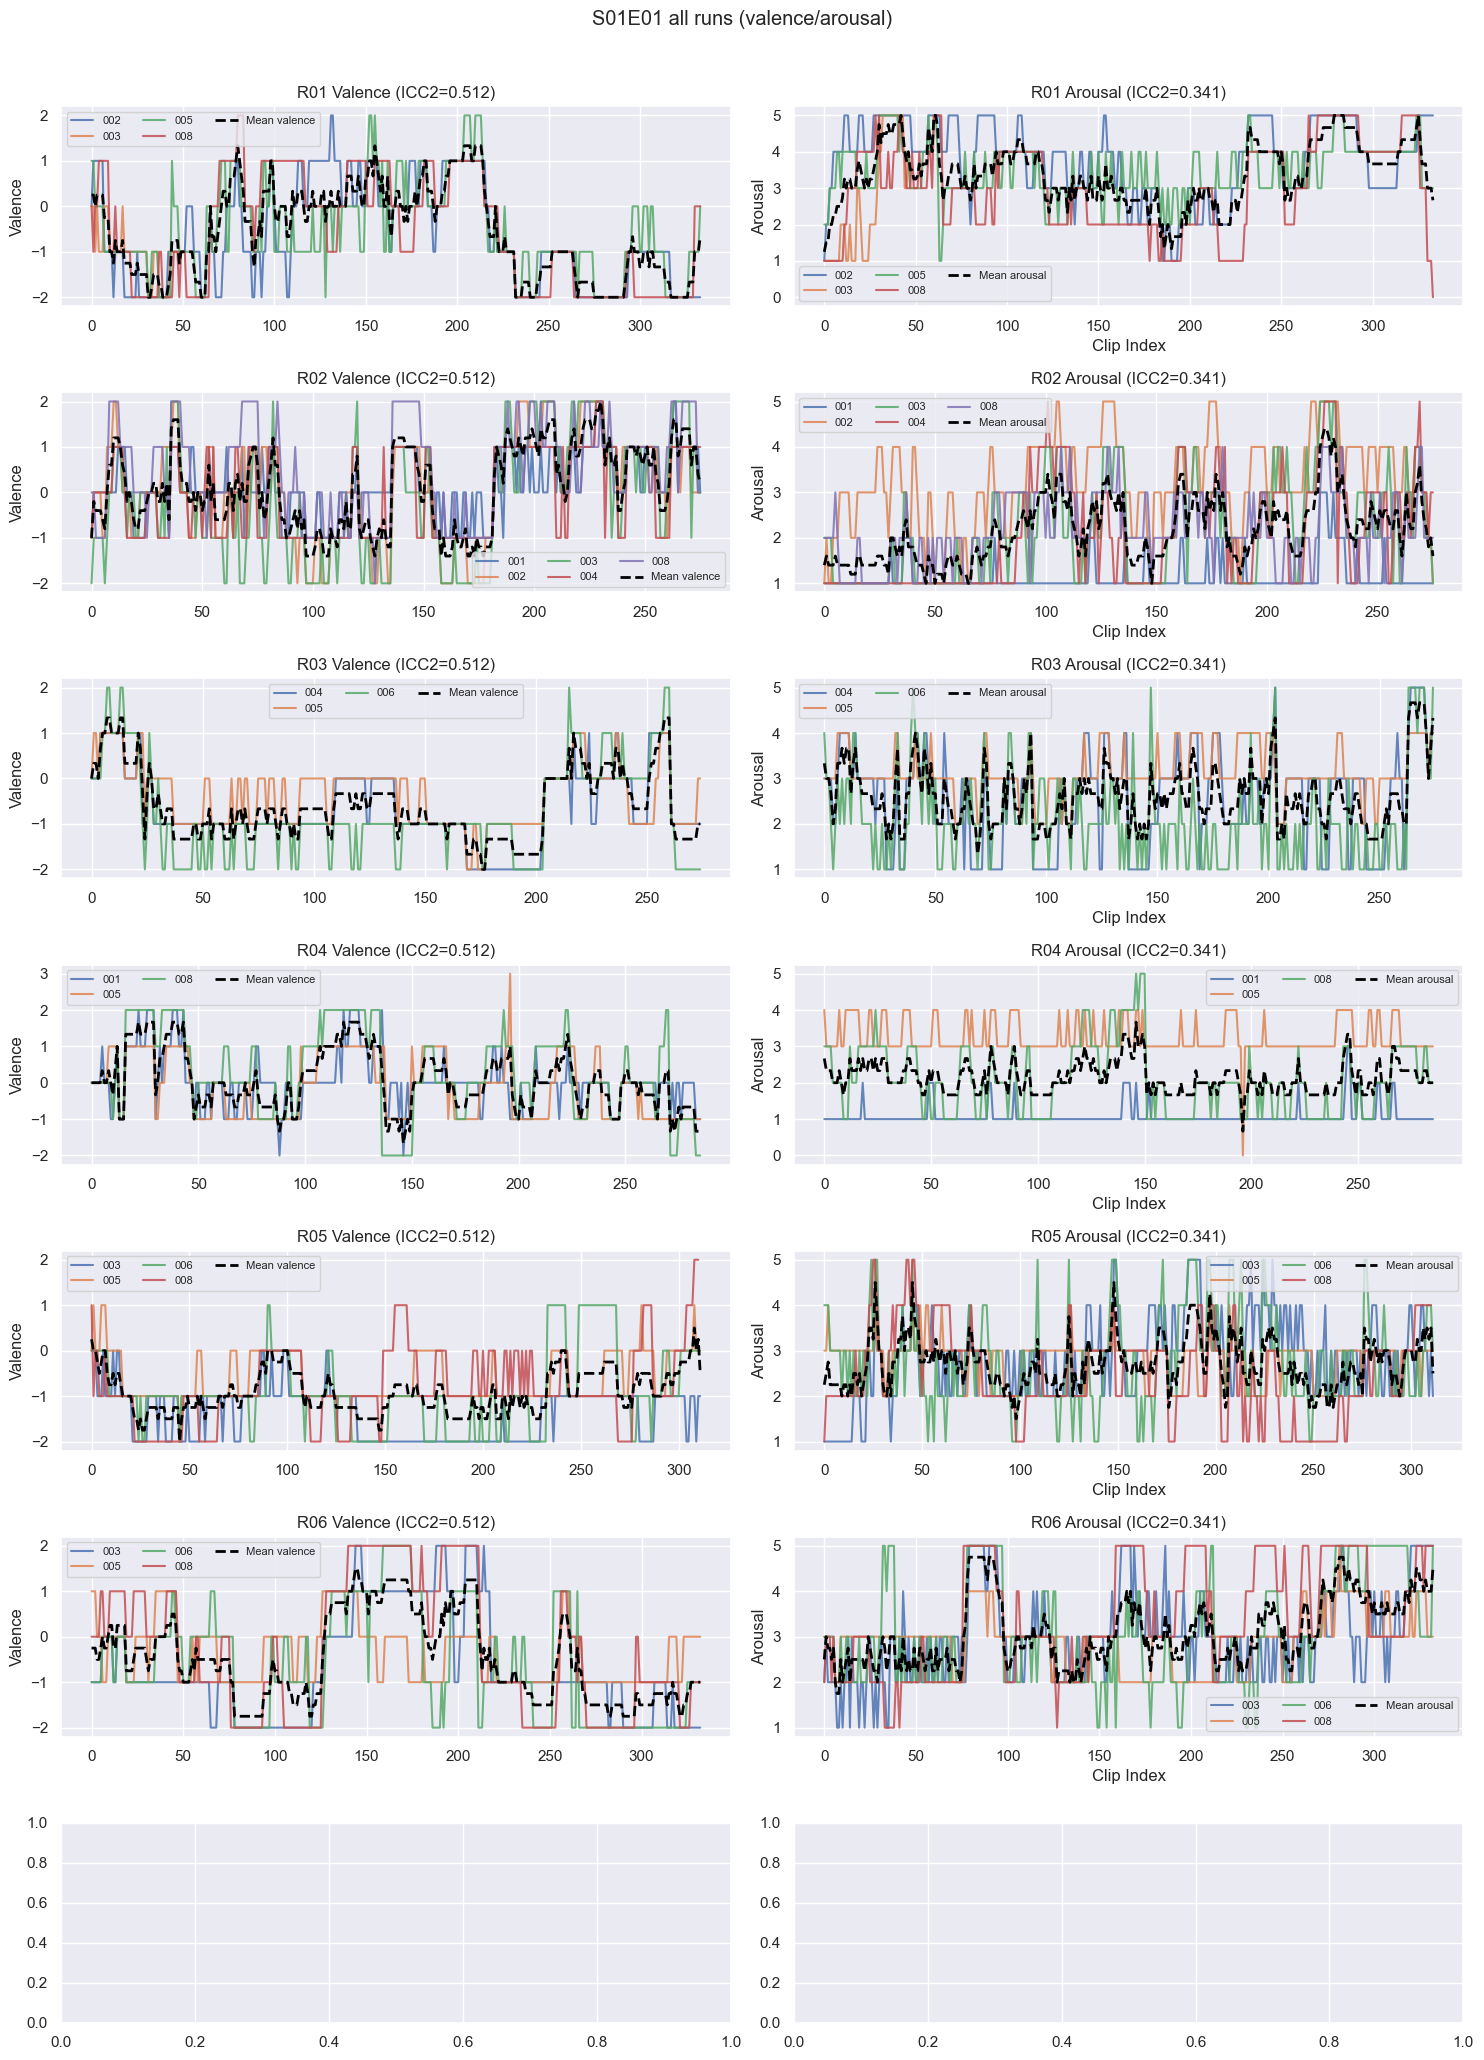

In [17]:
def compute_correlations(dfs, rating_type):
    if not dfs:
        return None
    
    wide_df = pd.DataFrame()
    raters = []
    for df in dfs:
        rater = df['rater'].iloc[0] # get rater name from 
        raters.append(rater)
        wide_df[rater] = df.set_index('time')[rating_type] # make time the index and then make raters as columns 

    corr_matrix = wide_df.corr(method='spearman')
    # set spearman ranked test as the correlation for the data frame

    import numpy as np
    triu_indices = np.triu_indices_from(corr_matrix, k=1)
    overall_avg_corr = corr_matrix.values[triu_indices].mean()  


episode_to_plot = "S01E01"
runs_to_plot = ["R01", "R02", "R03", "R04", "R05", "R06", "R07"]

# plotting valence and arousal for each run of the selected episode
n_runs = len(runs_to_plot)
fig, axs = plt.subplots(n_runs, 2, figsize=(15, 3 * n_runs), sharex=False)
fig.suptitle(f"{episode_to_plot} all runs (valence/arousal)")

for i, run_to_plot in enumerate(runs_to_plot):
    run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
    if not run_files:
        continue

    ax_val = axs[i, 0]
    ax_aro = axs[i, 1]
    dfs_val = []
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")
        if val_col is None or aro_col is None:
            continue

        rater_label = op.basename(file_path).split("_")[-1].replace(".csv", "")
        values = pd.to_numeric(df[val_col], errors="coerce")
        aros = pd.to_numeric(df[aro_col], errors="coerce")
        times = np.arange(len(df))

        dfs_val.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "valence": values
        }))
        dfs_aro.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "arousal": aros
        }))

        ax_val.plot(values.to_numpy(), label=rater_label, alpha=0.85)
        ax_aro.plot(aros.to_numpy(), label=rater_label, alpha=0.85)
    if dfs_val:
        wide_val = pd.DataFrame({
            df['rater'].iloc[0]: df.set_index('time')['valence']
            for df in dfs_val
    # plot average with graph
        })
        avg_val = wide_val.mean(axis=1)
        ax_val.plot(avg_val.index, avg_val.values,
                    color='black', linestyle='--', linewidth=2,
                    label='Mean valence')

    if dfs_aro:
        wide_aro = pd.DataFrame({
            df['rater'].iloc[0]: df.set_index('time')['arousal']
            for df in dfs_aro
     # plot average with graph

        })
        avg_aro = wide_aro.mean(axis=1)
        ax_aro.plot(avg_aro.index, avg_aro.values,
                    color='black', linestyle='--', linewidth=2,
                    label='Mean arousal')


    ax_val.set_title(f"{run_to_plot} Valence (ICC2={icc_val:.3f})")
    ax_val.set_ylabel("Valence")
    ax_val.legend(fontsize=8, ncol=3)

    ax_aro.set_title(f"{run_to_plot} Arousal (ICC2={icc_aro:.3f})")
    ax_aro.set_ylabel("Arousal")
    ax_aro.set_xlabel("Clip Index")
    ax_aro.legend(fontsize=8, ncol=3)


plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

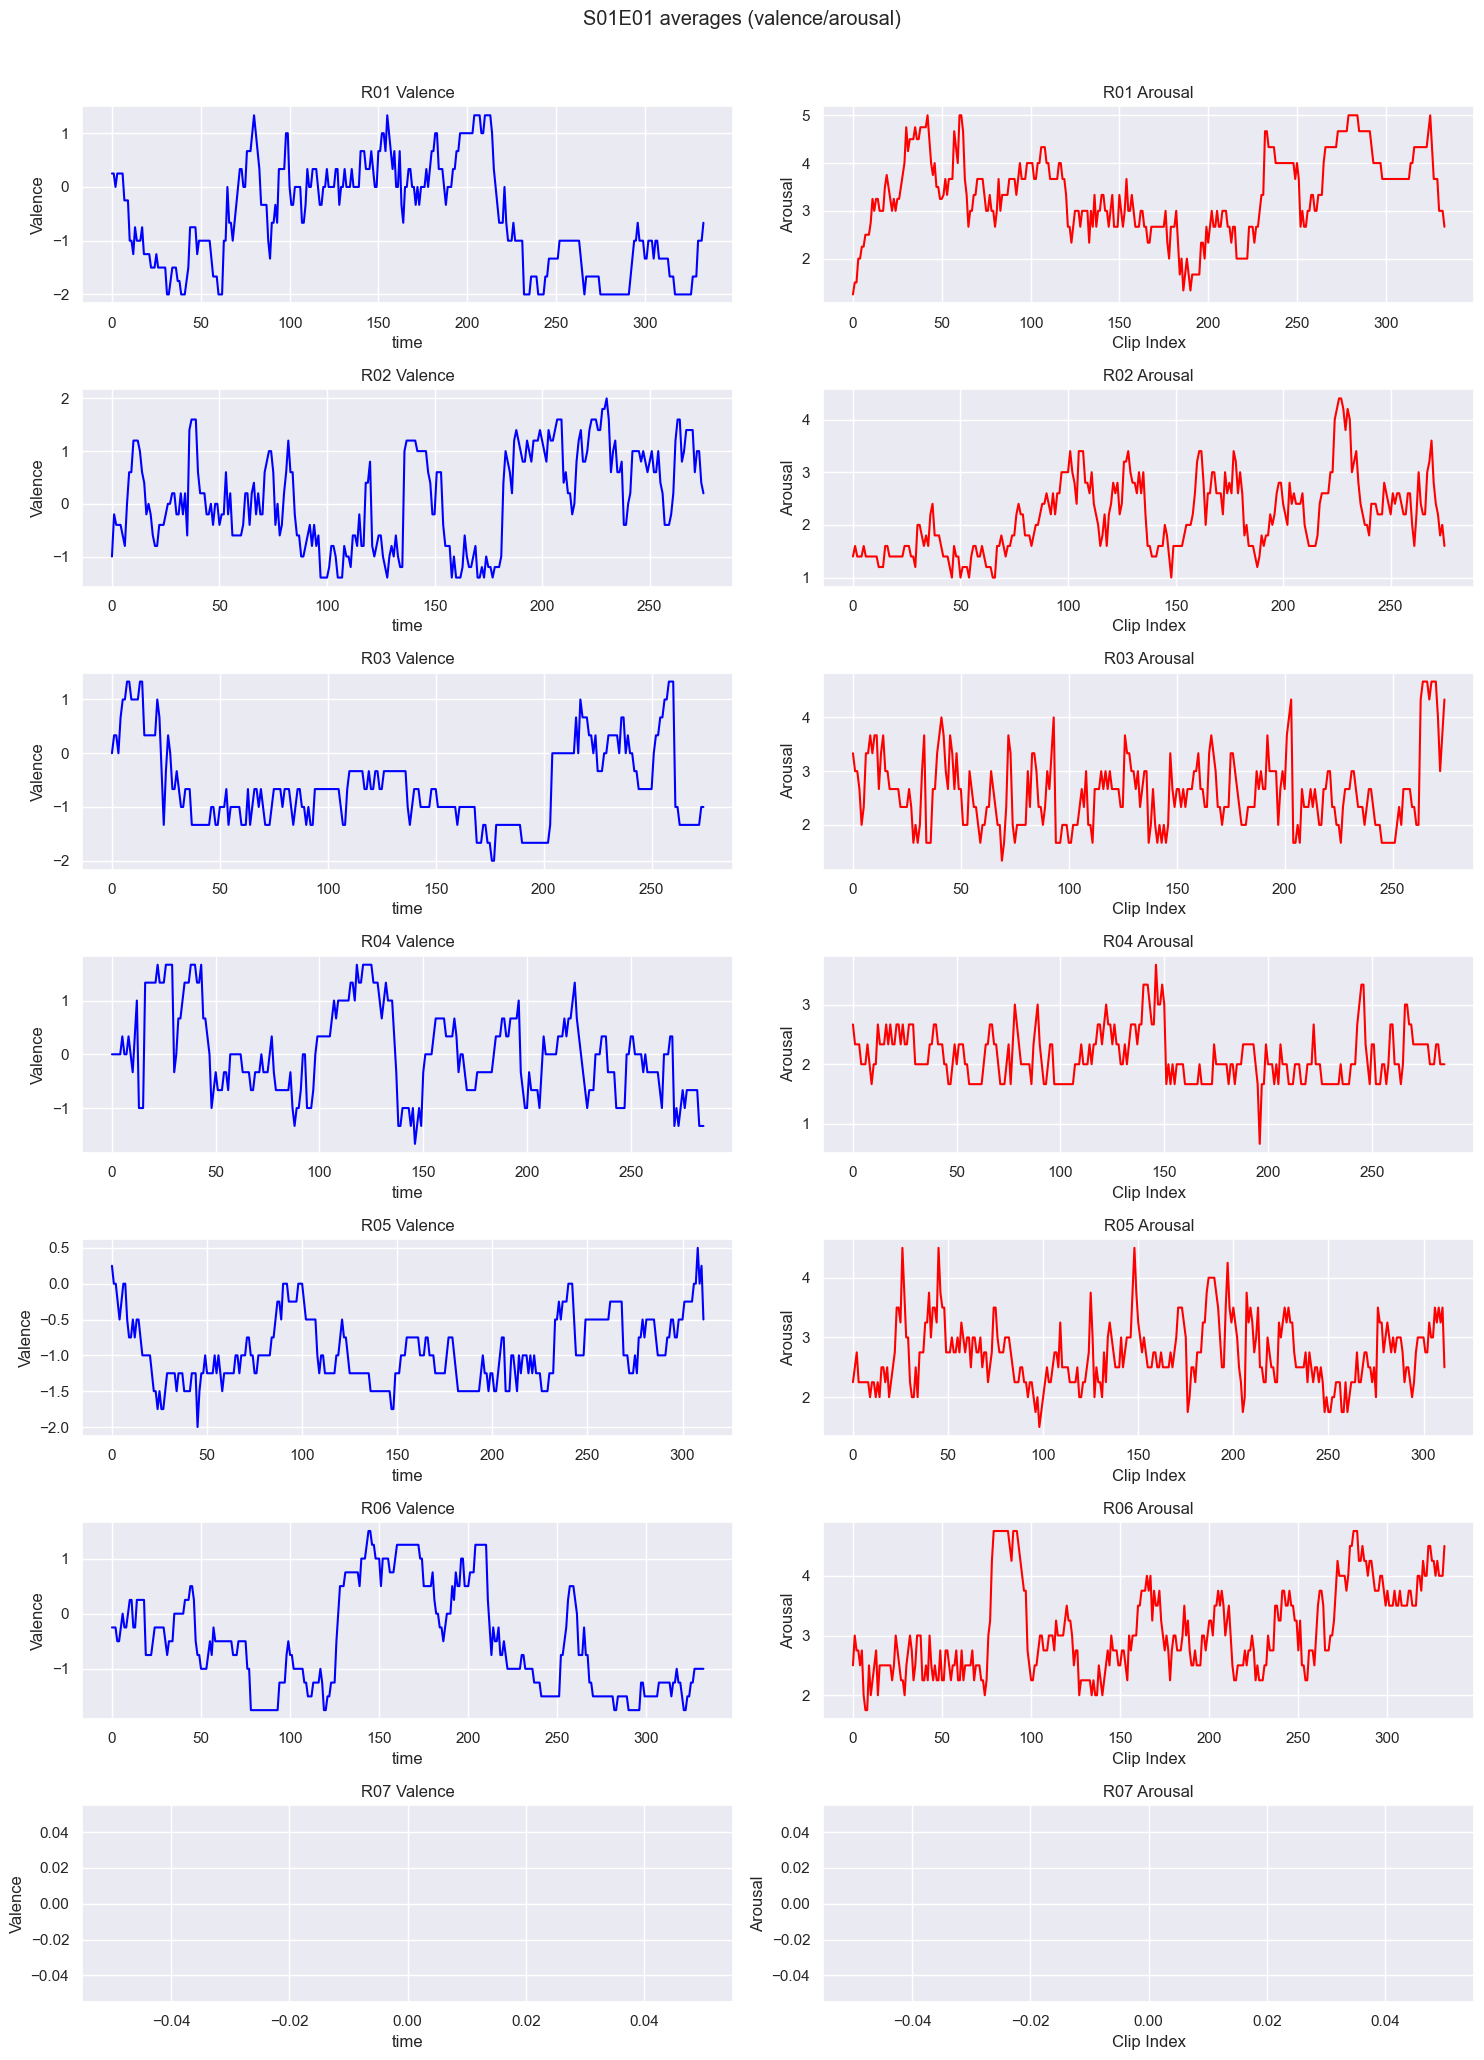

In [ ]:
episode_to_plot = "S01E01"
runs_to_plot = ["R01", "R02", "R03", "R04", "R05", "R06", "R07"]

avg_data = []
import seaborn as sns
sns.set_theme(style="darkgrid")

n_runs = len(runs_to_plot)
fig, axs = plt.subplots(n_runs, 2, figsize=(15, 3 * n_runs), sharex=False)
fig.suptitle(f"{episode_to_plot} averages (valence/arousal)")

for i, run_to_plot in enumerate(runs_to_plot):
    ax_val = axs[i, 0]
    ax_aro = axs[i, 1]
    
    run_files = episode_csvs.get(episode_to_plot, {}).get(run_to_plot, [])
    if not run_files:
        continue

    dfs_val = []
    dfs_aro = []

    for file_path in run_files:
        df = pd.read_csv(file_path)
        col_lookup = {c.lower(): c for c in df.columns}
        val_col = col_lookup.get("valence")
        aro_col = col_lookup.get("arousal")
        if val_col is None or aro_col is None:
            continue

        rater_label = op.basename(file_path).split("_")[-1].replace(".csv", "")
        values = pd.to_numeric(df[val_col], errors="coerce")
        aros = pd.to_numeric(df[aro_col], errors="coerce")
        times = np.arange(len(df))

        dfs_val.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "valence": values
        }))
        dfs_aro.append(pd.DataFrame({
            "time": times,
            "rater": rater_label,
            "arousal": aros
        }))

    if dfs_val:
        combined_val_df = pd.concat(dfs_val, ignore_index=True)
        sns.lineplot(x="time", y="valence", data=combined_val_df, ci='sd', ax=ax_val, color='blue', label='Valence (mean ± SD)')

    if dfs_aro:
        combined_aro_df = pd.concat(dfs_aro, ignore_index=True)
        sns.lineplot(x="time", y="arousal", data=combined_aro_df, ci='sd', ax=ax_aro, color='orange', label='Arousal (mean ± SD)')

    
    ax_val.set_title(f"{run_to_plot} Valence")
    ax_val.set_ylabel("Valence")

    ax_aro.set_title(f"{run_to_plot} Arousal")
    ax_aro.set_ylabel("Arousal")
    ax_aro.set_xlabel("Clip Index")

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()